Primer acercamiento a la estructura

In [1]:
import tables
import numpy as np
import matplotlib.pyplot as plt
from os.path import join

In [4]:
hdf5_filepath = "/home/sven-klein-plarre/Documentos/Universidad/Magister/Tesis/Dataset CTAO Monte Carlo Simulations - Eventlist on DL2 prod5/7298569/gamma-diffuse_with_images_00.dl2.h5"
hdf5_filepath_2 = "/home/sven-klein-plarre/Documentos/Universidad/Magister/Tesis/Dataset CTAO Monte Carlo Simulations - Eventlist on DL2 prod5/7298569/proton_with_images_00.dl2.h5"

In [5]:
def explorer(root):
    if(isinstance(root,tables.group.RootGroup) or isinstance(root,tables.group.Group)):
        print(root._g_getnchildren)
        for children in root:
            #if(isinstance(children,tables.table.Table)):
            #    print(children.cols._v_colnames)
            #    break
            explorer(children)
    elif(isinstance(root,tables.table.Table)):
        print(root.cols._v_colnames)
    else:
        print("Error de clase")

In [5]:
hdf5_file = tables.open_file(hdf5_filepath, "r")
hdf5_file_2 = tables.open_file(hdf5_filepath_2, "r")
r = hdf5_file.root
r_2 = hdf5_file_2.root
print(r.__class__)
print(r.dl1.monitoring.subarray.pointing.__class__)
test_dl1 = r["dl1"]
test_dl2 = r["dl2"]
#print(hdf5_file)

<class 'tables.group.RootGroup'>
<class 'tables.table.Table'>


In [9]:
explorer(r)
#print(hdf5_file)
#print(isinstance(r.dl1.monitoring.telescope.pointing,tables.group.Group))

<bound method Group._g_getnchildren of / (RootGroup) ''
  children := ['configuration' (Group), 'dl1' (Group), 'dl2' (Group), 'simulation' (Group)]>
<bound method Group._g_getnchildren of /configuration (Group) ''
  children := ['instrument' (Group), 'observation' (Group), 'simulation' (Group)]>
<bound method Group._g_getnchildren of /configuration/instrument (Group) ''
  children := ['subarray' (Group), 'telescope' (Group)]>
<bound method Group._g_getnchildren of /configuration/instrument/subarray (Group) ''
  children := ['layout' (Table)]>
['tel_id', 'name', 'type', 'pos_x', 'pos_y', 'pos_z', 'camera_name', 'optics_name', 'camera_index', 'optics_index', 'tel_description']
<bound method Group._g_getnchildren of /configuration/instrument/telescope (Group) ''
  children := ['camera' (Group), 'optics' (Table)]>
<bound method Group._g_getnchildren of /configuration/instrument/telescope/camera (Group) ''
  children := ['geometry_0' (Table), 'geometry_1' (Table), 'readout_0' (Table), 'read

In [11]:
print(r.dl1.event.subarray.trigger.cols._v_colnames)
print(r.dl1.event.subarray.trigger[0])

['obs_id', 'event_id', 'time', 'tels_with_trigger', 'event_type']
(5712, 74802, 59178.18607336, [False, False, False, False, False, False, False, False, False, False, False,  True, False], 32)


In [50]:
print(r.dl1._g_getnchildren)
print(r.dl1.monitoring._g_getnchildren)
print(r.dl1.monitoring.telescope._g_getnchildren)
print(r.dl1.monitoring.telescope.pointing._g_getnchildren)
print(r.dl1.monitoring.telescope.pointing.tel_001.cols._v_colnames)

<bound method Group._g_getnchildren of /dl1 (Group) ''
  children := ['event' (Group), 'monitoring' (Group), 'service' (Group)]>
<bound method Group._g_getnchildren of /dl1/monitoring (Group) ''
  children := ['subarray' (Group), 'telescope' (Group)]>
<bound method Group._g_getnchildren of /dl1/monitoring/telescope (Group) ''
  children := ['pointing' (Group)]>
<bound method Group._g_getnchildren of /dl1/monitoring/telescope/pointing (Group) ''
  children := ['tel_001' (Table), 'tel_002' (Table), 'tel_003' (Table), 'tel_004' (Table), 'tel_005' (Table), 'tel_006' (Table), 'tel_007' (Table), 'tel_008' (Table), 'tel_009' (Table), 'tel_010' (Table), 'tel_011' (Table), 'tel_019' (Table), 'tel_035' (Table)]>
['time', 'azimuth', 'altitude']


In [49]:
print(r.dl1.monitoring.subarray._g_getnchildren)
print(r.dl1.monitoring.subarray.pointing.cols._v_colnames)

<bound method Group._g_getnchildren of /dl1/monitoring/subarray (Group) ''
  children := ['pointing' (Table)]>
['time', 'array_azimuth', 'array_altitude', 'array_ra', 'array_dec']


In [52]:
print(r.dl1.service._g_getnchildren)
print(r.dl1.service.image_statistics.cols._v_colnames)

<bound method Group._g_getnchildren of /dl1/service (Group) ''
  children := ['image_statistics' (Table)]>
['criteria', 'counts', 'cumulative_counts', 'func']


In [6]:
print(r.dl1.event._g_getnchildren)
print(r.dl1.event.subarray._g_getnchildren)
print(r.dl1.event.subarray.trigger.cols._v_colnames)
print()
print(r.dl1.event.telescope._g_getnchildren)
print(r.dl1.event.telescope.trigger.cols._v_colnames)
print()
print(r.dl1.event.telescope.parameters._g_getnchildren)
print()
print(r.dl1.event.telescope.parameters.tel_001.cols._v_colnames)
#print(r.dl1.event.telescope.parameters.tel_001.read())
print(r.dl1.event.telescope.parameters.tel_001[0]['tel_id'])
print(r.dl1.event.telescope.images._g_getnchildren)
print(r.dl1.event.telescope.images.tel_001.cols._v_colnames)
print(len(r.dl1.event.telescope.images.tel_001[0]["image"]))
print()
print(r_2.dl1.event.telescope._g_getnchildren)
print(r_2.dl1.event.telescope.images.tel_001.cols._v_colnames)
print(len(r_2.dl1.event.telescope.images.tel_001[0]["image"]))

<bound method Group._g_getnchildren of /dl1/event (Group) ''
  children := ['subarray' (Group), 'telescope' (Group)]>
<bound method Group._g_getnchildren of /dl1/event/subarray (Group) ''
  children := ['trigger' (Table)]>
['obs_id', 'event_id', 'time', 'tels_with_trigger', 'event_type']

<bound method Group._g_getnchildren of /dl1/event/telescope (Group) ''
  children := ['images' (Group), 'parameters' (Group), 'trigger' (Table)]>
['obs_id', 'event_id', 'tel_id', 'time', 'n_trigger_pixels']

<bound method Group._g_getnchildren of /dl1/event/telescope/parameters (Group) ''
  children := ['tel_001' (Table), 'tel_002' (Table), 'tel_003' (Table), 'tel_004' (Table), 'tel_005' (Table), 'tel_006' (Table), 'tel_007' (Table), 'tel_008' (Table), 'tel_009' (Table), 'tel_010' (Table), 'tel_011' (Table), 'tel_019' (Table), 'tel_035' (Table)]>

['obs_id', 'event_id', 'tel_id', 'hillas_intensity', 'hillas_skewness', 'hillas_kurtosis', 'hillas_fov_lon', 'hillas_fov_lat', 'hillas_r', 'hillas_phi', 'hi

NoSuchNodeError: group ``/dl1/event/telescope`` does not have a child named ``images``

In [8]:
print(r._g_getnchildren)
print(r.configuration._g_getnchildren)
print(r.configuration.instrument._g_getnchildren)
print(r.configuration.instrument.subarray._g_getnchildren)
print()
print(r.configuration.instrument.subarray.layout.cols._v_colnames)
print()
print(r.configuration.instrument.subarray.layout.read())
print(type(r.configuration.instrument.subarray.layout.read()[0][2].decode("utf-8")))
for tel in r.configuration.instrument.subarray.layout:
    print(tel["tel_id"])

<bound method Group._g_getnchildren of / (RootGroup) ''
  children := ['configuration' (Group), 'dl1' (Group), 'dl2' (Group), 'simulation' (Group)]>
<bound method Group._g_getnchildren of /configuration (Group) ''
  children := ['instrument' (Group), 'observation' (Group), 'simulation' (Group)]>
<bound method Group._g_getnchildren of /configuration/instrument (Group) ''
  children := ['subarray' (Group), 'telescope' (Group)]>
<bound method Group._g_getnchildren of /configuration/instrument/subarray (Group) ''
  children := ['layout' (Table)]>

['tel_id', 'name', 'type', 'pos_x', 'pos_y', 'pos_z', 'camera_name', 'optics_name', 'camera_index', 'optics_index', 'tel_description']

[( 1, b'LST', b'LST',  -70.93,  -52.07, 43. , b'LSTCam', b'LST', 0, 0, b'LST_LST_LSTCam')
 ( 2, b'LST', b'LST',  -35.27,   66.14, 32. , b'LSTCam', b'LST', 0, 0, b'LST_LST_LSTCam')
 ( 3, b'LST', b'LST',   75.28,   50.49, 28.7, b'LSTCam', b'LST', 0, 0, b'LST_LST_LSTCam')
 ( 4, b'LST', b'LST',   30.91,  -64.54, 32. 

In [101]:
print(r.dl2.event.subarray.geometry.HillasReconstructor.cols._v_colnames)

['obs_id', 'event_id', 'HillasReconstructor_alt', 'HillasReconstructor_alt_uncert', 'HillasReconstructor_az', 'HillasReconstructor_az_uncert', 'HillasReconstructor_core_x', 'HillasReconstructor_core_y', 'HillasReconstructor_core_uncert_x', 'HillasReconstructor_core_uncert_y', 'HillasReconstructor_core_tilted_x', 'HillasReconstructor_core_tilted_y', 'HillasReconstructor_core_tilted_uncert_x', 'HillasReconstructor_core_tilted_uncert_y', 'HillasReconstructor_h_max', 'HillasReconstructor_h_max_uncert', 'HillasReconstructor_is_valid', 'HillasReconstructor_average_intensity', 'HillasReconstructor_goodness_of_fit', 'HillasReconstructor_telescopes']


In [7]:
print(r.simulation._g_getnchildren)
print(r.simulation.event._g_getnchildren)
print(r.simulation.event.subarray._g_getnchildren)
print(r.simulation.event.subarray.shower.cols._v_colnames)
print(r.simulation.event.subarray.shower.read())
#explorer(r.simulation)

<bound method Group._g_getnchildren of /simulation (Group) ''
  children := ['event' (Group), 'service' (Group)]>
<bound method Group._g_getnchildren of /simulation/event (Group) ''
  children := ['subarray' (Group), 'telescope' (Group)]>
<bound method Group._g_getnchildren of /simulation/event/subarray (Group) ''
  children := ['shower' (Table)]>
['obs_id', 'event_id', 'true_energy', 'true_alt', 'true_az', 'true_core_x', 'true_core_y', 'true_h_first_int', 'true_x_max', 'true_shower_primary_id']
[(5712,   74802, 19.67578125, 78.50238307,  17.19268751, 511.62863159, -295.44650269, 19403.3046875 , 473.64755249, 0)
 (5712,   74804, 19.67578125, 78.50238307,  17.19268751,  90.53171539,  -33.26006699, 19403.3046875 , 473.64755249, 0)
 (5712,   80503,  0.07350182, 73.0544671 ,   2.31290205, 129.20449829, -132.02418518, 25764.58203125, 248.18182373, 0)
 ...
 (5912, 4979504,  0.12531494, 68.01385579,   9.0323873 ,  29.64560127,   60.39186859, 26457.0546875 , 241.30435181, 0)
 (5912, 4979508,  

In [26]:
print(r.simulation.event.telescope.images._g_getnchildren)
print(r.simulation.event.telescope.images.tel_001.cols._v_colnames)
print(len(r.simulation.event.telescope.images.tel_001[0]["true_image"]))

<bound method Group._g_getnchildren of /simulation/event/telescope/images (Group) ''
  children := ['tel_001' (Table), 'tel_002' (Table), 'tel_003' (Table), 'tel_004' (Table), 'tel_005' (Table), 'tel_006' (Table), 'tel_007' (Table), 'tel_008' (Table), 'tel_009' (Table), 'tel_010' (Table), 'tel_011' (Table), 'tel_019' (Table), 'tel_035' (Table)]>
['obs_id', 'event_id', 'tel_id', 'true_image_sum', 'true_image']
1855


In [9]:
test_dl1._f_get_child

<bound method Group._f_get_child of /dl1 (Group) ''
  children := ['event' (Group), 'monitoring' (Group), 'service' (Group)]>

In [10]:
test_dl2._f_get_child

<bound method Group._f_get_child of /dl2 (Group) ''
  children := ['event' (Group), 'service' (Group)]>

In [11]:
dl1_event = test_dl1["event"]
dl1_monitoring = test_dl1["monitoring"]
dl1_service = test_dl1["service"]
dl2_event = test_dl2["event"]
dl2_service = test_dl2["service"]

In [1]:
import h5py

In [2]:
def explore_hdf5(name, obj):
    print(name)
    for key, val in obj.attrs.items():
        print(f"  Attr - {key}: {val}")

In [4]:
with h5py.File(hdf5_filepath, "r") as f:
    f.visititems(explore_hdf5)

configuration
  Attr - CLASS: b'GROUP'
  Attr - TITLE: Empty(dtype=dtype('S1'))
  Attr - VERSION: b'1.0'
configuration/instrument
  Attr - CLASS: b'GROUP'
  Attr - TITLE: Empty(dtype=dtype('S1'))
  Attr - VERSION: b'1.0'
configuration/instrument/subarray
  Attr - CLASS: b'GROUP'
  Attr - TITLE: Empty(dtype=dtype('S1'))
  Attr - VERSION: b'1.0'
configuration/instrument/subarray/layout
  Attr - CLASS: b'TABLE'
  Attr - CTAFIELD_10_MAXLEN: 17
  Attr - CTAFIELD_10_TRANSFORM: b'string'
  Attr - CTAFIELD_1_MAXLEN: 3
  Attr - CTAFIELD_1_TRANSFORM: b'string'
  Attr - CTAFIELD_2_MAXLEN: 3
  Attr - CTAFIELD_2_TRANSFORM: b'string'
  Attr - CTAFIELD_3_TRANSFORM: b'quantity'
  Attr - CTAFIELD_3_UNIT: b'm'
  Attr - CTAFIELD_4_TRANSFORM: b'quantity'
  Attr - CTAFIELD_4_UNIT: b'm'
  Attr - CTAFIELD_5_TRANSFORM: b'quantity'
  Attr - CTAFIELD_5_UNIT: b'm'
  Attr - CTAFIELD_6_MAXLEN: 9
  Attr - CTAFIELD_6_TRANSFORM: b'string'
  Attr - CTAFIELD_7_MAXLEN: 3
  Attr - CTAFIELD_7_TRANSFORM: b'string'
  Attr -

In [2]:
event_asociation_ids = {} #estructura que guarda la relación entre las id de telescopio, observación y evento
event_asociation_ids[1] = {}
event_asociation_ids[1]["a"] = []
event_asociation_ids[1]["a"].append("item1")
event_asociation_ids[1]["a"].append("casa")
event_asociation_ids[1]["b"] = []
event_asociation_ids[1]["b"].append("wea")
event_asociation_ids[2] = {}
event_asociation_ids[2]["a"] = []
event_asociation_ids[2]["a"].append("pico")
event_asociation_ids[2]["a"].append("pata")
event_asociation_ids[2]["a"].append("poto")
event_asociation_ids[2]["b"] = []
event_asociation_ids[2]["b"].append("oreja")
event_asociation_ids[2]["c"] = []
event_asociation_ids[2]["c"].append("nata")
#print(event_asociation_ids)
#print("a" in event_asociation_ids[1])
#print(len(event_asociation_ids[2]["c"]))
for fila in event_asociation_ids:
    #print(fila)
    for columna in event_asociation_ids[fila]:
        for item in event_asociation_ids[fila][columna]:
            print("["+str(fila)+","+columna+"] = "+item)
    #print(columna)

[1,a] = item1
[1,a] = casa
[1,b] = wea
[2,a] = pico
[2,a] = pata
[2,a] = poto
[2,b] = oreja
[2,c] = nata


In [6]:
for f,c in event_asociation_ids.items():
    print(f)
    print('c' in c.keys())
    print(len(c))
    print()

1
False
2

2
True
3



In [3]:
lista_a = [1,2,3,4]
lista_b = [1,2,5,6,7,8]
print(not set(lista_a).isdisjoint(lista_b))

True


In [37]:
mask = r.dl1.event.subarray.trigger[0]["tels_with_trigger"]
print(mask)
print(r.configuration.instrument.subarray.layout.read()[:]["tel_id"])
print(r.configuration.instrument.subarray.layout.read()[:]["tel_id"][mask])
print(type(r.configuration.instrument.subarray.layout.read()[:]["tel_id"][mask][0]))
li = r.configuration.instrument.subarray.layout.read()[:]["tel_id"]
print(str(li[0]) + "_" + str(li[1]))

[False False False False False False False False False False False  True
 False]
[ 1  2  3  4  5  6  7  8  9 10 11 35 19]
[35]
<class 'numpy.int16'>
1_2


In [36]:
separacion_test = ["12_34_5","56_78_9","10_11_12","13_14_5"]
separados = np.array([list(map(int, row.split("_"))) for row in separacion_test])
print(separados)
print(np.unique(separados[:,2]))

[[12 34  5]
 [56 78  9]
 [10 11 12]
 [13 14  5]]
[ 5  9 12]


In [19]:
tels_params = r.configuration.instrument.telescope
print(tels_params._f_get_child)
#print(tels_params.optics.cols._v_colnames)
#print(tels_params.optics[0])
print(tels_params.camera._g_getnchildren)
print(tels_params.camera.geometry_0.cols._v_colnames)
print(tels_params.camera.geometry_0[0:20])
print(tels_params.camera.readout_0.cols._v_colnames)
print(tels_params.camera.readout_0[0:20])

<bound method Group._f_get_child of /configuration/instrument/telescope (Group) ''
  children := ['camera' (Group), 'optics' (Table)]>
<bound method Group._g_getnchildren of /configuration/instrument/telescope/camera (Group) ''
  children := ['geometry_0' (Table), 'geometry_1' (Table), 'readout_0' (Table), 'readout_1' (Table)]>
['pix_id', 'pix_x', 'pix_y', 'pix_area']
[( 0,  0.        ,  0.        , 0.00207933)
 ( 1, -0.0377967 , -0.03273243, 0.00207933)
 ( 2, -0.04724547,  0.01636666, 0.00207933)
 ( 3, -0.00944877,  0.04909909, 0.00207933)
 ( 4,  0.0377967 ,  0.03273243, 0.00207933)
 ( 5,  0.04724547, -0.01636666, 0.00207933)
 ( 6,  0.00944877, -0.04909909, 0.00207933)
 ( 7, -0.07559331, -0.06546484, 0.00207933)
 ( 8, -0.08504208, -0.01636575, 0.00207933)
 ( 9, -0.09449085,  0.03273334, 0.00207933)
 (10, -0.05669425,  0.06546576, 0.00207933)
 (11, -0.01889755,  0.09819818, 0.00207933)
 (12,  0.02834793,  0.08183152, 0.00207933)
 (13,  0.07559331,  0.06546484, 0.00207933)
 (14,  0.0850

In [18]:
img = r.simulation.event.telescope.images
print(img.tel_001.cols._v_colnames)
print((img.tel_001[0]["true_image_sum"]))
print(r.configuration.instrument.subarray.layout.cols._v_colnames)
print(r.configuration.instrument.subarray.layout.read())#camera index indica la geometria de la cámara en el cuadro siguiente

['obs_id', 'event_id', 'tel_id', 'true_image_sum', 'true_image']
287
['tel_id', 'name', 'type', 'pos_x', 'pos_y', 'pos_z', 'camera_name', 'optics_name', 'camera_index', 'optics_index', 'tel_description']
[( 1, b'LST', b'LST',  -70.93,  -52.07, 43. , b'LSTCam', b'LST', 0, 0, b'LST_LST_LSTCam')
 ( 2, b'LST', b'LST',  -35.27,   66.14, 32. , b'LSTCam', b'LST', 0, 0, b'LST_LST_LSTCam')
 ( 3, b'LST', b'LST',   75.28,   50.49, 28.7, b'LSTCam', b'LST', 0, 0, b'LST_LST_LSTCam')
 ( 4, b'LST', b'LST',   30.91,  -64.54, 32. , b'LSTCam', b'LST', 0, 0, b'LST_LST_LSTCam')
 ( 5, b'MST', b'MST', -211.54,    5.66, 50.3, b'NectarCam', b'MST', 1, 1, b'MST_MST_NectarCam')
 ( 6, b'MST', b'MST', -153.26,  169.01, 24. , b'NectarCam', b'MST', 1, 1, b'MST_MST_NectarCam')
 ( 7, b'MST', b'MST',   27.07,  198.71, 12.2, b'NectarCam', b'MST', 1, 1, b'MST_MST_NectarCam')
 ( 8, b'MST', b'MST',  175.61,   73.06,  9. , b'NectarCam', b'MST', 1, 1, b'MST_MST_NectarCam')
 ( 9, b'MST', b'MST',  140.  , -189.  , 29. , b'Nect

<bound method Group._g_getnchildren of /configuration/instrument/telescope (Group) np.str_('')
  children := ['camera' (Group), 'optics' (Table)]>
<bound method Group._g_getnchildren of /configuration/instrument/telescope/camera (Group) np.str_('')
  children := ['geometry_0' (Table), 'geometry_1' (Table), 'readout_0' (Table), 'readout_1' (Table)]>
['pix_id', 'pix_x', 'pix_y', 'pix_area']
1855
[(   0,  0.        ,  0.        , 0.00207933)
 (   1, -0.0377967 , -0.03273243, 0.00207933)
 (   2, -0.04724547,  0.01636666, 0.00207933) ...
 (1852,  0.67088033, -0.96561883, 0.00207933)
 (1853, -0.45356484, -1.08017546, 0.00207933)
 (1854, -0.50081024, -1.06380875, 0.00207933)]

['pix_id', 'pix_x', 'pix_y', 'pix_area']
1855
[(   0, -0.45355293,  0.98198313, 0.00207933)
 (   1, -0.41575752,  1.01471541, 0.00207933)
 (   2, -0.42520629,  1.06381445, 0.00207933) ...
 (1852,  0.45355293, -0.98198313, 0.00207933)
 (1853,  0.41575752, -1.01471541, 0.00207933)
 (1854,  0.42520629, -1.06381445, 0.00207

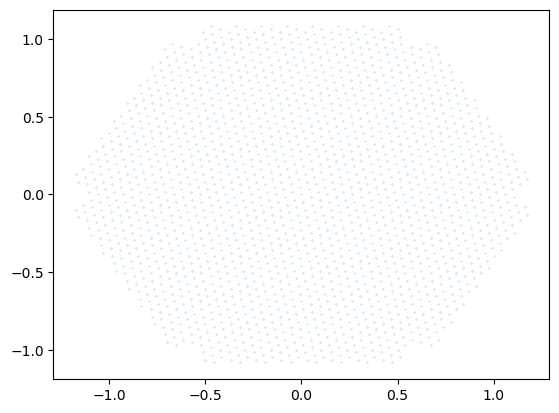

In [7]:
print(r.configuration.instrument.telescope._g_getnchildren)
print(r.configuration.instrument.telescope.camera._g_getnchildren)
print(r.configuration.instrument.telescope.camera.geometry_0.cols._v_colnames)
print(len(r.configuration.instrument.telescope.camera.geometry_0))
print(r.configuration.instrument.telescope.camera.geometry_0.read())
print()
print(r.configuration.instrument.telescope.camera.geometry_1.cols._v_colnames)
print(len(r.configuration.instrument.telescope.camera.geometry_1))
print(r.configuration.instrument.telescope.camera.geometry_1.read())
a_1 = r.configuration.instrument.telescope.camera.geometry_1.read()["pix_area"][0]
x_1 = r.configuration.instrument.telescope.camera.geometry_1.read()["pix_x"]
y_1 = r.configuration.instrument.telescope.camera.geometry_1.read()["pix_y"]
a_0 = r.configuration.instrument.telescope.camera.geometry_0.read()["pix_area"][0]
x_0 = r.configuration.instrument.telescope.camera.geometry_0.read()["pix_x"]
y_0 = r.configuration.instrument.telescope.camera.geometry_0.read()["pix_y"]
plt_1 = plt.scatter(x_1,y_1,s = a_1*10)
#plt.show()
#plt_0 = plt.scatter(x_0,y_0,s = a_0*10, c = "black")

In [62]:
TELESCOPES = ["LST_LSTCam", "MST_FlashCam", "SST1M_DigiCam"]
TELESCOPES_ALIAS = {
    "ML1": {
        "LST_LSTCam":    "LST", 
        "MST_FlashCam":  "MSTF", 
        "SST1M_DigiCam": "SST1"
    },
    "ML2": {
        "LST_LSTCam":    "LST_LSTCam", 
        "MST_FlashCam":  "MST_FlashCam",
        "SST1M_DigiCam": "SST1M_DigiCam"
    },
    "DL1": {
        "LST_LSTCam":    "LST",
        #"MST_NectarCam": "MST",    #Falta este tipo de cámara. Arreglar después
        "MST_FlashCam":  "MST",
        "SST1M_DigiCam": "SST"
    }
}
pix_pos_folder = "/home/sven-klein-plarre/Documentos/Universidad/Magister/Tesis/Repositorio-GERUMO/gerumo/gerumo/data/pixels_positions"

inverse_alias = {TELESCOPES_ALIAS["DL1"][t]:t for t in TELESCOPES}
modes = ('raw', 'simple', 'simple-shift')
pixpos_folder = join(pix_pos_folder, "DL1")
print(pixpos_folder)
type_geometry_dict = {}
raw_pixpos = {}
all_pixpos = {}
telescopes_info = hdf5_file.root.configuration.instrument.subarray.layout
geometry_group = hdf5_file.root.configuration.instrument.telescope.camera
for tel in telescopes_info:
    tipo = tel["type"].decode("utf-8")
    if tipo not in type_geometry_dict:
        type_geometry_dict[tipo] = tel["camera_index"]
for t in type_geometry_dict:
    if t not in inverse_alias:
        continue
    geometry_index = "geometry_" + str(type_geometry_dict[t])
    raw_pixpos[t] = []
    geometry = geometry_group[geometry_index]
    num_pixels = len(geometry)
    for pixel in geometry:
        raw_pixpos[t].append(np.array([pixel["pix_x"],pixel["pix_y"]]))
all_pixpos['raw'] = {}
for telescope, pixpos in raw_pixpos.items():
    if telescope == TELESCOPES_ALIAS["DL1"]["LST_LSTCam"]:
        LST_LSTCam_not_aligm = pixpos
        all_pixpos['raw']['LST_LSTCam_not_aligm'] = LST_LSTCam_not_aligm
        raw_pixpos[telescope] = LST_LSTCam_align(pixpos)
        pixpos = raw_pixpos[telescope]
        np.savetxt(join(pixpos_folder,'raw', f'{telescope}_not_align.npy'), LST_LSTCam_not_aligm)
    np.savetxt(join(pixpos_folder,'raw', f'{telescope}.npy'), pixpos)
    all_pixpos['raw'][telescope] = pixpos

/home/sven-klein-plarre/Documentos/Universidad/Magister/Tesis/Repositorio-GERUMO/gerumo/gerumo/data/pixels_positions/DL1


NameError: name 'LST_LSTCam_align' is not defined

In [5]:
load_data_ML1_LST_not_align = np.load('/home/sven-klein-plarre/Documentos/Universidad/Magister/Tesis/Repositorio-GERUMO/gerumo/gerumo/data/pixels_positions/ML1/raw/LST_LSTCam_not_align.npy')
load_data_ML1_LST_align = np.loadtxt('/home/sven-klein-plarre/Documentos/Universidad/Magister/Tesis/Repositorio-GERUMO/gerumo/gerumo/data/pixels_positions/ML1/raw/LST_LSTCam.npy')
load_data_ML1_LST_simple = np.loadtxt('/home/sven-klein-plarre/Documentos/Universidad/Magister/Tesis/Repositorio-GERUMO/gerumo/gerumo/data/pixels_positions/ML1/simple/LST_LSTCam.npy')
load_data_ML1_LST_simple_shift = np.loadtxt('/home/sven-klein-plarre/Documentos/Universidad/Magister/Tesis/Repositorio-GERUMO/gerumo/gerumo/data/pixels_positions/ML1/simple_shift/LST_LSTCam.npy')
load_data_ML1_LST_time = np.loadtxt('/home/sven-klein-plarre/Documentos/Universidad/Magister/Tesis/Repositorio-GERUMO/gerumo/gerumo/data/pixels_positions/ML1/time/LST_LSTCam.npy')
load_data_ML1_LST_time_shift = np.loadtxt('/home/sven-klein-plarre/Documentos/Universidad/Magister/Tesis/Repositorio-GERUMO/gerumo/gerumo/data/pixels_positions/ML1/time_shift/LST_LSTCam.npy')

Text(0.5, 1.0, 'Raw not aligned pixels')

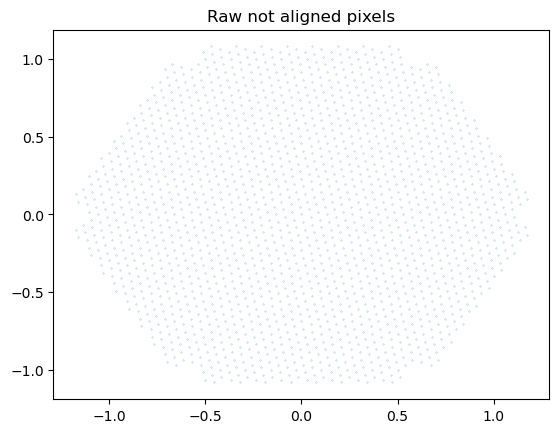

In [8]:
load_x_ML1_not_align = load_data_ML1_LST_not_align[0]
load_y_ML1_not_align = load_data_ML1_LST_not_align[1]
plt.scatter(load_x_ML1_not_align,load_y_ML1_not_align, s=a_1*10)
plt.title("Raw not aligned pixels")

Text(0.5, 1.0, 'Raw aligned pixels')

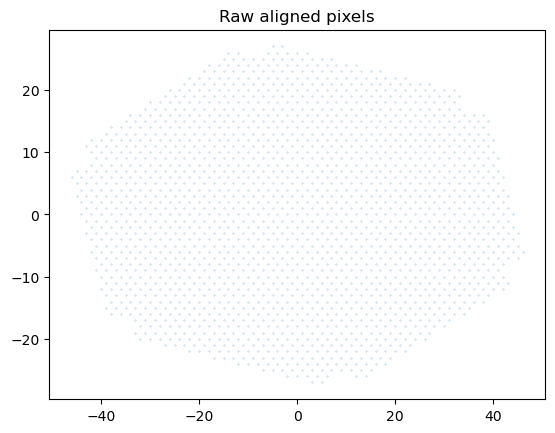

In [9]:
load_x_ML1_align = load_data_ML1_LST_align[0]
load_y_ML1_align = load_data_ML1_LST_align[1]
plt.scatter(load_x_ML1_align,load_y_ML1_align, s=a_1*10)
plt.title("Raw aligned pixels")

Text(0.5, 1.0, 'Simple')

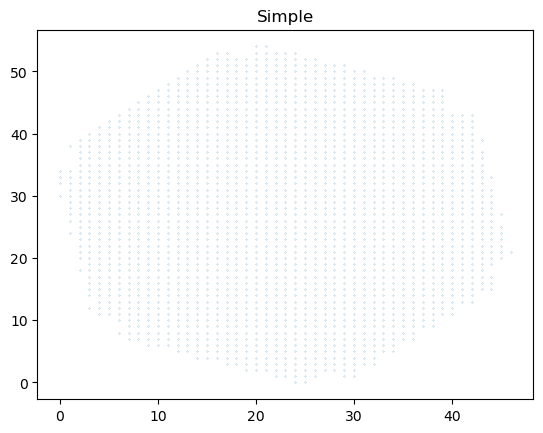

In [10]:
load_x_ML1_simple = load_data_ML1_LST_simple[0]
load_y_ML1_simple = load_data_ML1_LST_simple[1]
plt.scatter(load_x_ML1_simple,load_y_ML1_simple, s=a_1*10)
plt.title("Simple")

Text(0.5, 1.0, 'Simple shifted pixels')

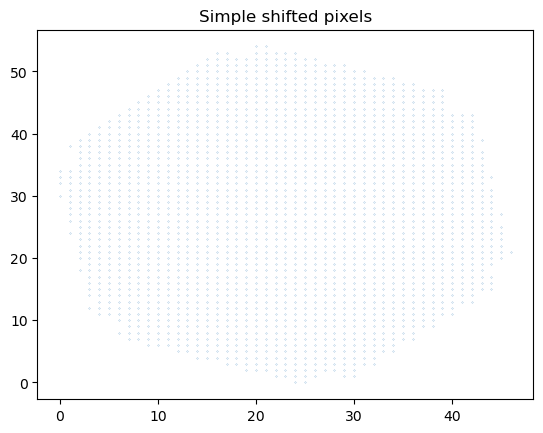

In [20]:
load_x_ML1_simple_shift = load_data_ML1_LST_simple_shift[1]
load_y_ML1_simple_shift = load_data_ML1_LST_simple_shift[2]
plt.scatter(load_x_ML1_simple_shift,load_y_ML1_simple_shift, s=a_1*10)
plt.title("Simple shifted pixels")

Text(0.5, 1.0, 'Time')

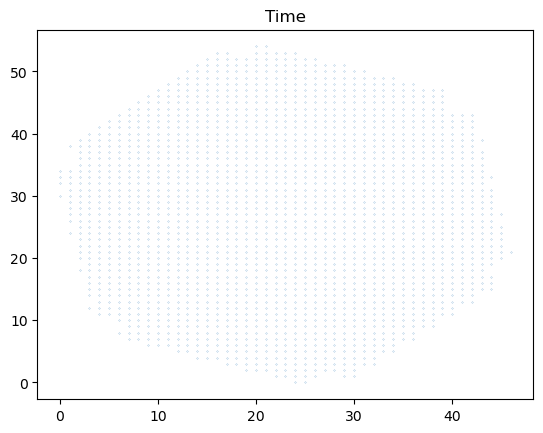

In [12]:
load_x_ML1_time = load_data_ML1_LST_time[0]
load_y_ML1_time = load_data_ML1_LST_time[1]
plt.scatter(load_x_ML1_time,load_y_ML1_time, s=a_1*10)
plt.title("Time")

Text(0.5, 1.0, 'Time shift')

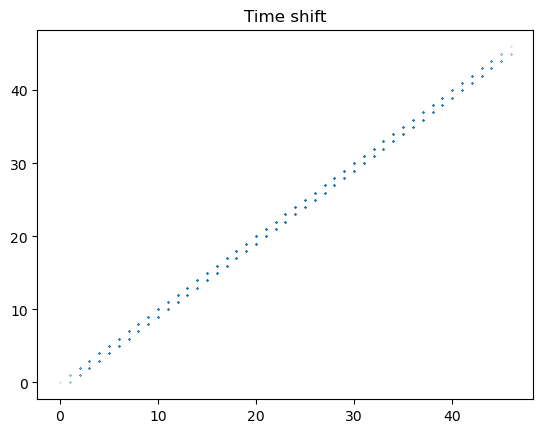

In [13]:
load_x_ML1_time_shift = load_data_ML1_LST_time_shift[0]
load_y_ML1_time_shift = load_data_ML1_LST_time_shift[1]
plt.scatter(load_x_ML1_time_shift,load_y_ML1_time_shift, s=a_1*10)
plt.title("Time shift")

In [14]:
load_data_DL1_LST_simple_shift = np.loadtxt('/home/sven-klein-plarre/Documentos/Universidad/Magister/Tesis/Repositorio-GERUMO/gerumo/gerumo/data/pixels_positions/DL1/simple_shift/LST.npy')
#load_data = np.loadtxt('/home/sven-klein-plarre/Documentos/Universidad/Magister/Tesis/Repositorio-GERUMO/gerumo/gerumo/data/pixels_positions/ML1/raw/SST1M_DigiCam.npy')
load_x_DL1 = load_data_DL1_LST_simple_shift[0]
load_y_DL1 = load_data_DL1_LST_simple_shift[1]
load_z_DL1 = load_data_DL1_LST_simple_shift[2]

#figura3d = plt.figure()
#ax = figura3d.add_subplot(projection='3d')
#ax.scatter(load_x_DL1,load_y_DL1,load_z_DL1, s=a_1*10)
#ax.set_xlabel("X")
#ax.set_ylabel("Y")
#ax.set_zlabel("Z")
plt.scatter(load_x_DL1,load_z_DL1, s=a_1*10)

FileNotFoundError: /home/sven-klein-plarre/Documentos/Universidad/Magister/Tesis/Repositorio-GERUMO/gerumo/gerumo/data/pixels_positions/DL1/simple_shift/LST.npy not found.

In [18]:
geo = r.configuration.instrument.telescope.camera.geometry_0.read()

pix_x = geo["pix_x"]
pix_y = geo["pix_y"]
np.allclose(pix_y,load_y_ML1_not_align)

False

In [23]:
np.allclose(load_data_ML1_LST_simple_shift,load_data_ML1_LST_time_shift)

True